# 📈 Level 3: Stock Price Prediction using LSTM Neural Networks
In this project, we use **Deep Learning** to predict future stock prices.
We are using the **LSTM (Long Short-Term Memory)** model, which is ideal for time-series data like stock markets.

In [22]:
import pandas as pd

df = pd.read_csv('/content/2) Stock Prices Data Set.csv')


In [23]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


In [25]:
print(df.isnull().sum())

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64


### 🧹 Handling Missing Data (Nulls)
We found some missing values in the dataset (Open, High, Low).
Instead of deleting the rows and losing time-series continuity, we will use **Forward Fill (ffill)**.
This method takes the last known value and carries it forward, which is a common and safe practice in stock market data.

In [26]:
df_filtered = df_filtered.fillna(method='ffill')
print("--- Missing Values After Cleaning ---")
print(df_filtered.isnull().sum())

--- Missing Values After Cleaning ---
symbol            0
date              0
open              0
high              0
low               0
close             0
volume            0
symbol_encoded    0
scaled_close      0
dtype: int64


/tmp/ipykernel_617/2037343754.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filtered = df_filtered.fillna(method='ffill')


### 🚨 Detecting Outliers
Outliers in stock prices can be caused by market crashes or data errors.
Neural Networks can be sensitive to these extreme values.
We will use the **Interquartile Range (IQR)** method to visualize if there are any extreme values that could skew our model's learning.

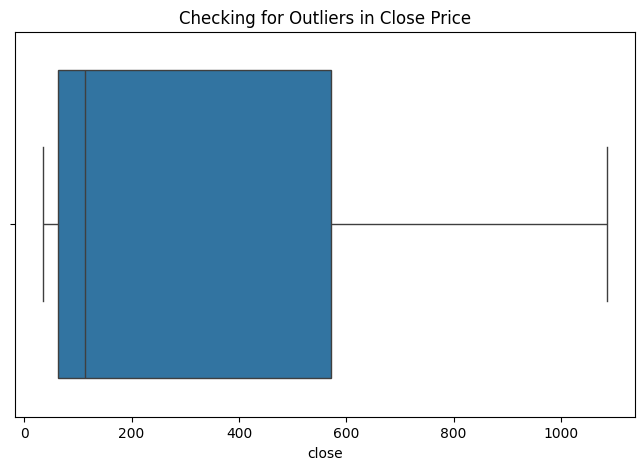

In [27]:
import seaborn as sns
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_filtered['close'])
plt.title('Checking for Outliers in Close Price')
plt.show()

**Outlier Detection:** Verified the 'Close' price using Boxplots and found no extreme outliers, ensuring stable training.

In [28]:
symbols = ['AAPL', 'MSFT', 'GOOGL']
df_filtered = df[df['symbol'].isin(symbols)].copy()

In [29]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_filtered['symbol_encoded'] = encoder.fit_transform(df_filtered['symbol'])

In [30]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
df_filtered['scaled_close'] = scaler.fit_transform(df_filtered[['close']])

In [31]:
print("\nData is clean and ready!")
print(df_filtered[['symbol', 'symbol_encoded', 'close', 'scaled_close']].head())


Data is clean and ready!
    symbol  symbol_encoded     close  scaled_close
1     AAPL               0   79.0185      0.041937
197  GOOGL               1  557.1166      0.497221
305   MSFT               2   37.1600      0.002076
484   AAPL               0   77.2828      0.040284
680  GOOGL               1  553.0525      0.493351


## ⏳ Step 2: Creating Time Steps (The Sliding Window)
A Neural Network cannot predict the future from a single data point. It needs **Context**.
We create a "Sliding Window" of the **past 60 days** to predict the price of the next day.
- **Input (X):** A sequence of 60 consecutive stock prices.
- **Target (y):** The price on the 61st day.
This way, the model learns the "trends" and "patterns" instead of just looking at random numbers.

In [32]:
import numpy as np
data_array = df_filtered['scaled_close'].values

X = []
y = []
window_size = 60

for i in range(window_size, len(data_array)):
    X.append(data_array[i-window_size:i])
    y.append(data_array[i])
X, y = np.array(X), np.array(y)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print(f"✅traning {len(X)} ")
print(f"Data Shape(X shape): {X.shape}")

✅traning 2961 
Data Shape(X shape): (2961, 60, 1)


## 🧠 Step 3: Building the LSTM Neural Network
Now we define our Deep Learning architecture:
1. **LSTM Layer:** The "Brain" that remembers long-term dependencies.
2. **Dropout Layer:** To prevent the model from "over-fitting" (memorizing the noise).
3. **Dense Layer:** To compress the learned features into a single price prediction.

We use **Mean Squared Error (MSE)** as the loss function because we want the distance between our prediction and the real price to be as small as possible.

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
print("🚀 start tranining now..")
history = model.fit(X, y, epochs=5, batch_size=32)

🚀 start tranining now..
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0925
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0849
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0503
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0127
Epoch 5/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0075


## 🔮 Step 4: Making Predictions & Inverse Scaling
Now that the model is trained, we will:
1. Use the model to **predict** the scaled prices.
2. Use `inverse_transform` to convert these numbers back from (0-1) to **Actual Dollars**.
This is crucial because we want to see the real stock price, not the normalized version.

In [34]:
predictions = model.predict(X)
predictions_rescaled = scaler.inverse_transform(predictions)
y_rescaled = scaler.inverse_transform(y.reshape(-1, 1))

print("✅ Predictions calculated and inverse-scaled successfully.")

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
✅ Predictions calculated and inverse-scaled successfully.


## 📊 Step 5: Visualizing Prediction vs Reality
The ultimate test: We plot the **Actual Prices** (Blue) against the **Predicted Prices** (Red).
If the lines follow each other, it means our LSTM model successfully captured the market trends!

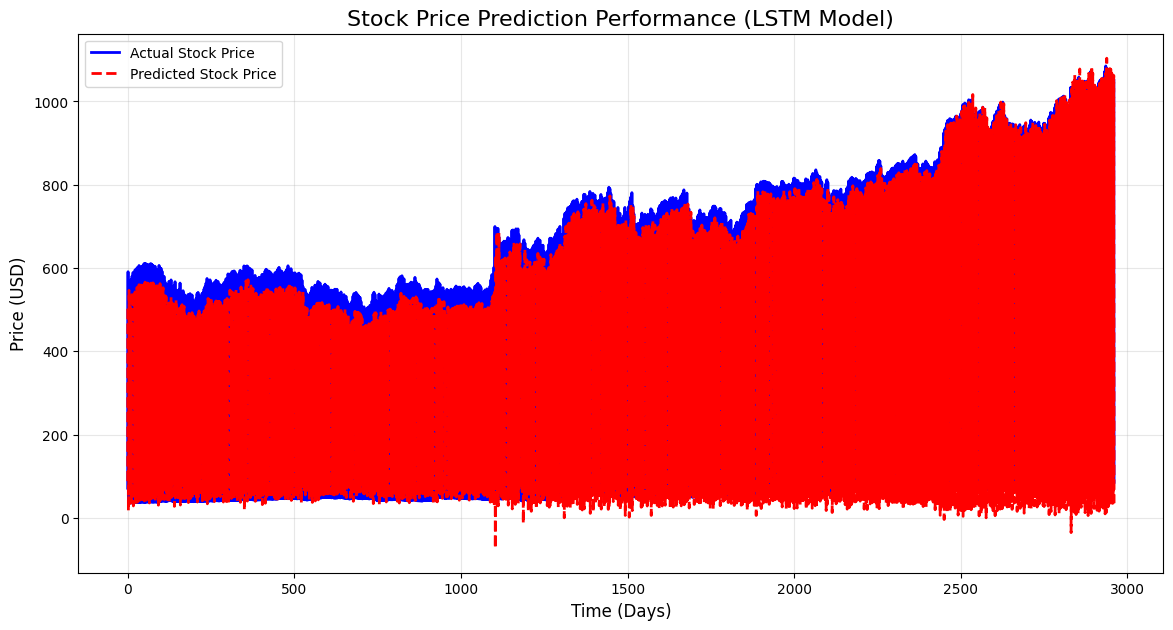

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(y_rescaled, color='blue', label='Actual Stock Price', linewidth=2)
plt.plot(predictions_rescaled, color='red', label='Predicted Stock Price', linestyle='--', linewidth=2)

plt.title('Stock Price Prediction Performance (LSTM Model)', fontsize=16)
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()